In [1]:
!pip install tensorflow

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2,
    fill_mode='nearest'
)


In [4]:
train_generator = train_datagen.flow_from_directory(
    'Dataset/images.cv_jzk6llhf18tm3k0kyttxz/data/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 6225 images belonging to 11 classes.


In [5]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    'Dataset/images.cv_jzk6llhf18tm3k0kyttxz/data/test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False   # Important for evaluation
)

Found 3187 images belonging to 11 classes.


In [ ]:
val_datagen = ImageDataGenerator(rescale=1./255)

val_generator = val_datagen.flow_from_directory(
    'Dataset/images.cv_jzk6llhf18tm3k0kyttxz/data/val',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 1092 images belonging to 11 classes.


In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models


In [8]:
model = models.Sequential([
    
    # First Convolution Block
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D((2,2)),
    
    # Second Convolution Block
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    # Third Convolution Block
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    # Flatten Layer
    layers.Flatten(),
    
    # Fully Connected Layer
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    
    # Output Layer
    layers.Dense(train_generator.num_classes, activation='softmax')
])

C:\Users\sekhar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
# Compiling the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,379 (42.61 MB)

 Trainable params: 11,170,379 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20
)

Epoch 1/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 668s 3s/step - accuracy: 0.3401 - loss: 1.8776 - val_accuracy: 0.6410 - val_loss: 1.2631
Epoch 2/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 327s 2s/step - accuracy: 0.5062 - loss: 1.3812 - val_accuracy: 0.7610 - val_loss: 0.9252
Epoch 3/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 337s 2s/step - accuracy: 0.6079 - loss: 1.1192 - val_accuracy: 0.7225 - val_loss: 0.8662
Epoch 4/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 354s 2s/step - accuracy: 0.6586 - loss: 0.9686 - val_accuracy: 0.8022 - val_loss: 0.6267
Epoch 5/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 312s 2s/step - accuracy: 0.6866 - loss: 0.8700 - val_accuracy: 0.8168 - val_loss: 0.6223
Epoch 6/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 306s 2s/step - accuracy: 0.7247 - loss: 0.7619 - val_accuracy: 0.8278 - val_loss: 0.4784
Epoch 7/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 307s 2s/step - accuracy: 0.7320 - loss: 0.7649 - val_accuracy: 0.8306 - val_loss: 0.4869
Epoch 8/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 303s 2s/step - accuracy: 0.7613 - loss: 0.6611 - val_accu

In [12]:
model.save("cnn_fish_model.h5")

In [13]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16, ResNet50, MobileNet, InceptionV3, EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D

In [14]:
def build_model(base_model, num_classes):

    # Freeze base model
    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)

    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [15]:
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))
vgg_model = build_model(vgg_base, train_generator.num_classes)

vgg_history = vgg_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 1965s 10s/step - accuracy: 0.3827 - loss: 1.8372 - val_accuracy: 0.6374 - val_loss: 1.3538
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 2114s 11s/step - accuracy: 0.6076 - loss: 1.2451 - val_accuracy: 0.7866 - val_loss: 0.8972
Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 2098s 11s/step - accuracy: 0.6949 - loss: 0.9746 - val_accuracy: 0.8214 - val_loss: 0.6883
Epoch 4/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 2080s 11s/step - accuracy: 0.7423 - loss: 0.8042 - val_accuracy: 0.8535 - val_loss: 0.5649
Epoch 5/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 2021s 10s/step - accuracy: 0.7764 - loss: 0.6994 - val_accuracy: 0.8993 - val_loss: 0.4601
Epoch 6/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 2003s 10s/step - accuracy: 0.8005 - loss: 0.6132 - val_accuracy: 0.8974 - val_loss: 0.4165
Epoch 7/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 1998s 10s/step - accuracy: 0.8313 - loss: 0.5530 - val_accuracy: 0.9158 - val_loss: 0.3681
Epoch 8/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 1984s 10s/step - accuracy: 0.8315 - loss: 0

In [16]:
resnet_base = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
resnet_model = build_model(resnet_base, train_generator.num_classes)

resnet_history = resnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 681s 3s/step - accuracy: 0.1618 - loss: 2.3350 - val_accuracy: 0.1712 - val_loss: 2.2610
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 678s 3s/step - accuracy: 0.1762 - loss: 2.2562 - val_accuracy: 0.1777 - val_loss: 2.1980
Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 673s 3s/step - accuracy: 0.1862 - loss: 2.2142 - val_accuracy: 0.1886 - val_loss: 2.1499
Epoch 4/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 662s 3s/step - accuracy: 0.1928 - loss: 2.1763 - val_accuracy: 0.1923 - val_loss: 2.1102
Epoch 5/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 656s 3s/step - accuracy: 0.1933 - loss: 2.1559 - val_accuracy: 0.2170 - val_loss: 2.0820
Epoch 6/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 628s 3s/step - accuracy: 0.2026 - loss: 2.1378 - val_accuracy: 0.2335 - val_loss: 2.0490
Epoch 7/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 597s 3s/step - accuracy: 0.2135 - loss: 2.1164 - val_accuracy: 0.2857 - val_loss: 2.0521
Epoch 8/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 600s 3s/step - accuracy: 0.2141 - loss: 2.1191 - val_accu

In [17]:
mobilenet_base = MobileNet(weights='imagenet', include_top=False, input_shape=(224,224,3))
mobilenet_model = build_model(mobilenet_base, train_generator.num_classes)

mobilenet_history = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 206s 1s/step - accuracy: 0.6959 - loss: 0.9094 - val_accuracy: 0.9505 - val_loss: 0.2006
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 199s 1s/step - accuracy: 0.9057 - loss: 0.3068 - val_accuracy: 0.9716 - val_loss: 0.0930
Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 198s 1s/step - accuracy: 0.9356 - loss: 0.2054 - val_accuracy: 0.9835 - val_loss: 0.0571
Epoch 4/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 197s 1s/step - accuracy: 0.9492 - loss: 0.1568 - val_accuracy: 0.9881 - val_loss: 0.0443
Epoch 5/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 196s 1s/step - accuracy: 0.9508 - loss: 0.1491 - val_accuracy: 0.9872 - val_loss: 0.0345
Epoch 6/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 200s 1s/step - accuracy: 0.9608 - loss: 0.1245 - val_accuracy: 0.9918 - val_loss: 0.0299
Epoch 7/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 195s 1s/step - accuracy: 0.9656 - loss: 0.1078 - val_accuracy: 0.9945 - val_loss: 0.0235
Epoch 8/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 194s 991ms/step - accuracy: 0.9661 - loss: 0.1025 - val_a

In [18]:
inception_base = InceptionV3(weights='imagenet', include_top=False, input_shape=(224,224,3))
inception_model = build_model(inception_base, train_generator.num_classes)

inception_history = inception_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 442s 2s/step - accuracy: 0.6103 - loss: 1.1671 - val_accuracy: 0.9038 - val_loss: 0.4068
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 426s 2s/step - accuracy: 0.7944 - loss: 0.6183 - val_accuracy: 0.9185 - val_loss: 0.2637
Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 429s 2s/step - accuracy: 0.8323 - loss: 0.4920 - val_accuracy: 0.9588 - val_loss: 0.2047
Epoch 4/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 425s 2s/step - accuracy: 0.8596 - loss: 0.4167 - val_accuracy: 0.9533 - val_loss: 0.1580
Epoch 5/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 426s 2s/step - accuracy: 0.8651 - loss: 0.3897 - val_accuracy: 0.9579 - val_loss: 0.1373
Epoch 6/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 426s 2s/step - accuracy: 0.8856 - loss: 0.3476 - val_accuracy: 0.9661 - val_loss: 0.1181
Epoch 7/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 431s 2s/step - accuracy: 0.8779 - loss: 0.3610 - val_accuracy: 0.9670 - val_loss: 0.1104
Epoch 8/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 426s 2s/step - accuracy: 0.8917 - loss: 0.3189 - val_accu

In [19]:
efficientNetB0_base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))
efficientNetB0_model = build_model(efficientNetB0_base, train_generator.num_classes)

efficient_history = efficientNetB0_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 242s 1s/step - accuracy: 0.1526 - loss: 2.3522 - val_accuracy: 0.1712 - val_loss: 2.3137
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 228s 1s/step - accuracy: 0.1709 - loss: 2.3260 - val_accuracy: 0.1712 - val_loss: 2.3126
Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 229s 1s/step - accuracy: 0.1754 - loss: 2.3162 - val_accuracy: 0.1712 - val_loss: 2.3100
Epoch 4/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 226s 1s/step - accuracy: 0.1761 - loss: 2.3113 - val_accuracy: 0.1712 - val_loss: 2.3105
Epoch 5/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 226s 1s/step - accuracy: 0.1761 - loss: 2.3039 - val_accuracy: 0.1712 - val_loss: 2.3120
Epoch 6/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 227s 1s/step - accuracy: 0.1761 - loss: 2.3065 - val_accuracy: 0.1712 - val_loss: 2.3095
Epoch 7/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 227s 1s/step - accuracy: 0.1761 - loss: 2.3053 - val_accuracy: 0.1712 - val_loss: 2.3105
Epoch 8/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 227s 1s/step - accuracy: 0.1761 - loss: 2.3022 - val_accu

In [20]:
models = {
    "VGG16": vgg_model,
    "ResNet50": resnet_model,
    "MobileNet": mobilenet_model,
    "InceptionV3": inception_model,
    "EfficientNetB0": efficientNetB0_model
}

for name, model in models.items():
    loss, acc = model.evaluate(val_generator)
    print(f"{name} Accuracy: {acc:.4f}")

35/35 ━━━━━━━━━━━━━━━━━━━━ 279s 8s/step - accuracy: 0.9295 - loss: 0.2718
VGG16 Accuracy: 0.9295
35/35 ━━━━━━━━━━━━━━━━━━━━ 92s 3s/step - accuracy: 0.2958 - loss: 2.0081
ResNet50 Accuracy: 0.2958
35/35 ━━━━━━━━━━━━━━━━━━━━ 20s 582ms/step - accuracy: 0.9918 - loss: 0.0207
MobileNet Accuracy: 0.9918
35/35 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.9634 - loss: 0.1163
InceptionV3 Accuracy: 0.9634
35/35 ━━━━━━━━━━━━━━━━━━━━ 26s 737ms/step - accuracy: 0.1712 - loss: 2.3109
EfficientNetB0 Accuracy: 0.1712


In [21]:
def fine_tune_model(model, base_model, layers_to_unfreeze=20):

    # Unfreeze last few layers
    for layer in base_model.layers[-layers_to_unfreeze:]:
        layer.trainable = True

    # Keep earlier layers frozen
    for layer in base_model.layers[:-layers_to_unfreeze]:
        layer.trainable = False

    # Recompile with low learning rate
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [22]:
# Fine-tune VGG16
vgg_model = fine_tune_model(vgg_model, vgg_base, layers_to_unfreeze=20)

vgg_finetune_history = vgg_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 7654s 39s/step - accuracy: 0.8170 - loss: 0.5953 - val_accuracy: 0.9112 - val_loss: 0.2605
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 7668s 39s/step - accuracy: 0.9425 - loss: 0.1919 - val_accuracy: 0.9826 - val_loss: 0.0574
Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 7666s 39s/step - accuracy: 0.9598 - loss: 0.1372 - val_accuracy: 0.9762 - val_loss: 0.0663
Epoch 4/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 7685s 39s/step - accuracy: 0.9778 - loss: 0.0791 - val_accuracy: 0.9725 - val_loss: 0.0996
Epoch 5/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 7696s 39s/step - accuracy: 0.9698 - loss: 0.1211 - val_accuracy: 0.9844 - val_loss: 0.0420
Epoch 6/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 7915s 41s/step - accuracy: 0.9782 - loss: 0.0717 - val_accuracy: 0.9899 - val_loss: 0.0271
Epoch 7/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 7936s 41s/step - accuracy: 0.9775 - loss: 0.0775 - val_accuracy: 0.9844 - val_loss: 0.0486
Epoch 8/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 8100s 42s/step - accuracy: 0.9815 - loss: 0

In [23]:
resnet_model = fine_tune_model(resnet_model, resnet_base, 30)

resnet_finetune_history=resnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10)

Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 949s 5s/step - accuracy: 0.2003 - loss: 2.4396 - val_accuracy: 0.2079 - val_loss: 2.1031
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 922s 5s/step - accuracy: 0.2411 - loss: 2.0786 - val_accuracy: 0.3773 - val_loss: 1.9210
Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 922s 5s/step - accuracy: 0.2847 - loss: 1.9647 - val_accuracy: 0.3800 - val_loss: 1.9104
Epoch 4/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 922s 5s/step - accuracy: 0.3309 - loss: 1.8721 - val_accuracy: 0.2665 - val_loss: 3.4124
Epoch 5/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 916s 5s/step - accuracy: 0.3730 - loss: 1.7636 - val_accuracy: 0.4469 - val_loss: 1.6493
Epoch 6/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 916s 5s/step - accuracy: 0.4042 - loss: 1.6697 - val_accuracy: 0.4679 - val_loss: 1.4928
Epoch 7/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 915s 5s/step - accuracy: 0.4379 - loss: 1.5866 - val_accuracy: 0.4780 - val_loss: 1.4347
Epoch 8/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 920s 5s/step - accuracy: 0.4410 - loss: 1.5728 - val_accu

In [24]:
mobilenet_model = fine_tune_model(mobilenet_model, mobilenet_base, 20)

mobilenet_finetune_history=mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10)

Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 262s 1s/step - accuracy: 0.9043 - loss: 0.5653 - val_accuracy: 0.9908 - val_loss: 0.0253
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 254s 1s/step - accuracy: 0.9782 - loss: 0.0750 - val_accuracy: 0.9954 - val_loss: 0.0206
Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 255s 1s/step - accuracy: 0.9818 - loss: 0.0563 - val_accuracy: 0.9963 - val_loss: 0.0181
Epoch 4/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 254s 1s/step - accuracy: 0.9876 - loss: 0.0401 - val_accuracy: 0.9973 - val_loss: 0.0155
Epoch 5/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 253s 1s/step - accuracy: 0.9886 - loss: 0.0365 - val_accuracy: 0.9945 - val_loss: 0.0220
Epoch 6/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 257s 1s/step - accuracy: 0.9897 - loss: 0.0353 - val_accuracy: 0.9963 - val_loss: 0.0163
Epoch 7/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 254s 1s/step - accuracy: 0.9912 - loss: 0.0269 - val_accuracy: 0.9982 - val_loss: 0.0138
Epoch 8/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 254s 1s/step - accuracy: 0.9910 - loss: 0.0259 - val_accu

In [25]:
inception_model = fine_tune_model(inception_model, inception_base, 30)

inception_finetune_history=inception_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10)

Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 482s 2s/step - accuracy: 0.8787 - loss: 0.3793 - val_accuracy: 0.9826 - val_loss: 0.0676
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 467s 2s/step - accuracy: 0.9418 - loss: 0.1692 - val_accuracy: 0.9835 - val_loss: 0.0512
Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 464s 2s/step - accuracy: 0.9566 - loss: 0.1344 - val_accuracy: 0.9835 - val_loss: 0.0505
Epoch 4/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 464s 2s/step - accuracy: 0.9684 - loss: 0.1051 - val_accuracy: 0.9899 - val_loss: 0.0384
Epoch 5/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 464s 2s/step - accuracy: 0.9701 - loss: 0.1007 - val_accuracy: 0.9890 - val_loss: 0.0355
Epoch 6/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 467s 2s/step - accuracy: 0.9685 - loss: 0.0981 - val_accuracy: 0.9899 - val_loss: 0.0276
Epoch 7/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 464s 2s/step - accuracy: 0.9799 - loss: 0.0732 - val_accuracy: 0.9908 - val_loss: 0.0235
Epoch 8/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 534s 3s/step - accuracy: 0.9799 - loss: 0.0684 - val_accu

In [26]:
efficientNetB0_model = fine_tune_model(efficientNetB0_model, efficientNetB0_base, 30)

efficientNetB0_finetune_history=efficientNetB0_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10)

Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 318s 1s/step - accuracy: 0.1711 - loss: 2.3206 - val_accuracy: 0.1712 - val_loss: 2.3138
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 296s 2s/step - accuracy: 0.1757 - loss: 2.3011 - val_accuracy: 0.1712 - val_loss: 2.3115
Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 316s 2s/step - accuracy: 0.1757 - loss: 2.2990 - val_accuracy: 0.1712 - val_loss: 2.3140
Epoch 4/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 269s 1s/step - accuracy: 0.1757 - loss: 2.3001 - val_accuracy: 0.1712 - val_loss: 2.3101
Epoch 5/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 267s 1s/step - accuracy: 0.1761 - loss: 2.3010 - val_accuracy: 0.1712 - val_loss: 2.3107
Epoch 6/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 267s 1s/step - accuracy: 0.1761 - loss: 2.2998 - val_accuracy: 0.1712 - val_loss: 2.3106
Epoch 7/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 268s 1s/step - accuracy: 0.1761 - loss: 2.2995 - val_accuracy: 0.1712 - val_loss: 2.3106
Epoch 8/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 267s 1s/step - accuracy: 0.1761 - loss: 2.3011 - val_accu

In [27]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    "best_fish_model.h5",     # file name
    monitor='val_accuracy',   # track validation accuracy
    save_best_only=True,      # only save best model
    mode='max',               # maximize accuracy
    verbose=1
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[checkpoint]
)

Epoch 1/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1788 - loss: 2.2968
Epoch 1: val_accuracy improved from None to 0.17125, saving model to best_fish_model.h5



Epoch 1: finished saving model to best_fish_model.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 267s 1s/step - accuracy: 0.1761 - loss: 2.2996 - val_accuracy: 0.1712 - val_loss: 2.3108
Epoch 2/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1735 - loss: 2.3037
Epoch 2: val_accuracy did not improve from 0.17125
195/195 ━━━━━━━━━━━━━━━━━━━━ 267s 1s/step - accuracy: 0.1761 - loss: 2.2987 - val_accuracy: 0.1712 - val_loss: 2.3087
Epoch 3/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1779 - loss: 2.2985
Epoch 3: val_accuracy did not improve from 0.17125
195/195 ━━━━━━━━━━━━━━━━━━━━ 273s 1s/step - accuracy: 0.1761 - loss: 2.3021 - val_accuracy: 0.1712 - val_loss: 2.3088
Epoch 4/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1783 - loss: 2.2950
Epoch 4: val_accuracy did not improve from 0.17125
195/195 ━━━━━━━━━━━━━━━━━━━━ 266s 1s/step - accuracy: 0.1761 - loss: 2.2986 - val_accuracy: 0.1712 - val_loss: 2.3092
Epoch 5/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1


Epoch 20: finished saving model to best_fish_model.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 266s 1s/step - accuracy: 0.1810 - loss: 2.2622 - val_accuracy: 0.2225 - val_loss: 2.2514


In [28]:
model.save("Final_Fish_Model.h5")

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [30]:
models = {
    "CNN": model,
    "VGG16": vgg_model,
    "ResNet50": resnet_model,
    "MobileNet": mobilenet_model,
    "InceptionV3": inception_model,
    "EfficientNetB0": efficientNetB0_model
}

histories = {
    "CNN": history,
    "VGG16": vgg_history,
    "ResNet50": resnet_history,
    "MobileNet": mobilenet_history,
    "InceptionV3": inception_history,
    "EfficientNetB0": efficient_history
}

In [ ]:
results = {}

for name, model in models.items():
    
    print(f"\n  EVALUATING {name}")
    
    # Predictions
    y_pred = model.predict(val_generator)
    y_pred = np.argmax(y_pred, axis=1)
    y_true = val_generator.classes
    
    # Accuracy
    acc = accuracy_score(y_true, y_pred)
    
    # Classification Report (Precision, Recall, F1)
    print(classification_report(y_true, y_pred))
    
    print("Accuracy:", acc)
    
    results[name] = acc


🔹 CNN
35/35 ━━━━━━━━━━━━━━━━━━━━ 32s 848ms/step


C:\Users\sekhar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sekhar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sekhar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classific

              precision    recall  f1-score   support

           0       0.17      0.83      0.28       187
           1       0.00      0.00      0.00        10
           2       0.00      0.00      0.00       105
           3       0.00      0.00      0.00        94
           4       0.00      0.00      0.00        97
           5       0.00      0.00      0.00        90
           6       0.00      0.00      0.00       113
           7       0.00      0.00      0.00        97
           8       0.06      0.10      0.07       100
           9       0.00      0.00      0.00       101
          10       0.00      0.00      0.00        98

    accuracy                           0.15      1092
   macro avg       0.02      0.08      0.03      1092
weighted avg       0.03      0.15      0.06      1092

Accuracy: 0.152014652014652

🔹 VGG16
35/35 ━━━━━━━━━━━━━━━━━━━━ 280s 8s/step
              precision    recall  f1-score   support

           0       0.15      0.13      0.14       187
 

C:\Users\sekhar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sekhar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sekhar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classific

35/35 ━━━━━━━━━━━━━━━━━━━━ 22s 603ms/step
              precision    recall  f1-score   support

           0       0.16      0.16      0.16       187
           1       0.17      0.10      0.12        10
           2       0.08      0.08      0.08       105
           3       0.07      0.07      0.07        94
           4       0.01      0.01      0.01        97
           5       0.12      0.12      0.12        90
           6       0.12      0.12      0.12       113
           7       0.10      0.10      0.10        97
           8       0.06      0.06      0.06       100
           9       0.15      0.15      0.15       101
          10       0.08      0.08      0.08        98

    accuracy                           0.10      1092
   macro avg       0.10      0.10      0.10      1092
weighted avg       0.10      0.10      0.10      1092

Accuracy: 0.10164835164835165

🔹 InceptionV3
35/35 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step
              precision    recall  f1-score   support

      

C:\Users\sekhar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sekhar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sekhar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classific

35/35 ━━━━━━━━━━━━━━━━━━━━ 26s 736ms/step


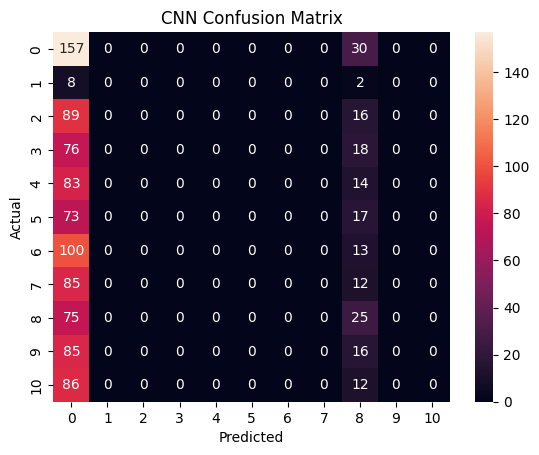

35/35 ━━━━━━━━━━━━━━━━━━━━ 280s 8s/step


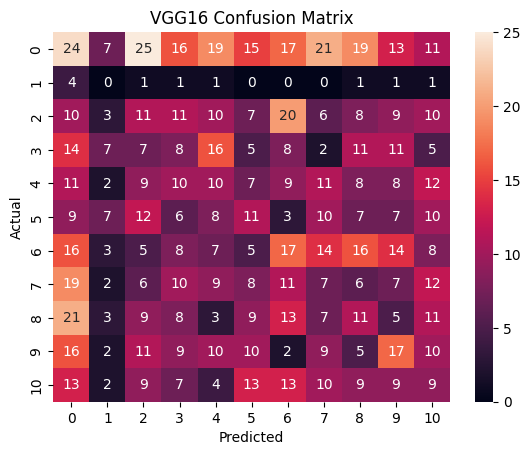

35/35 ━━━━━━━━━━━━━━━━━━━━ 98s 3s/step


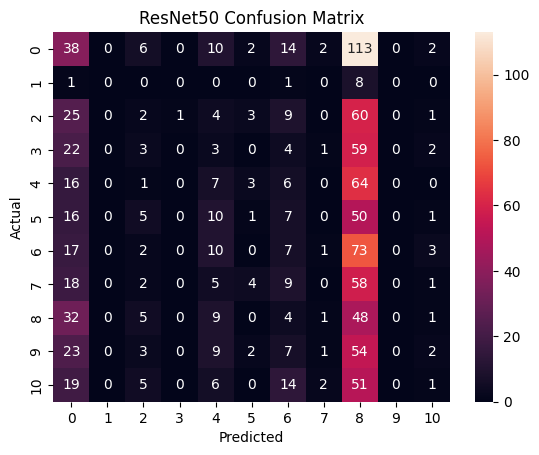

35/35 ━━━━━━━━━━━━━━━━━━━━ 23s 643ms/step


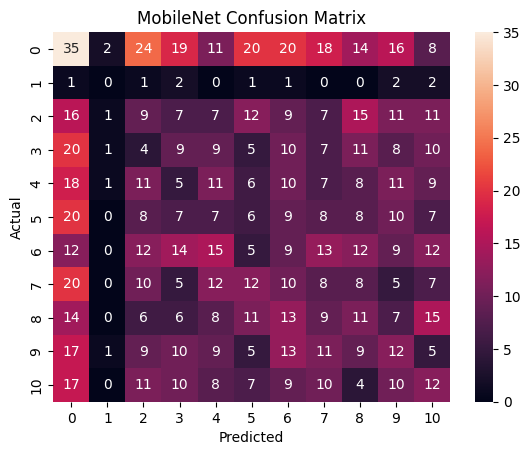

35/35 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step


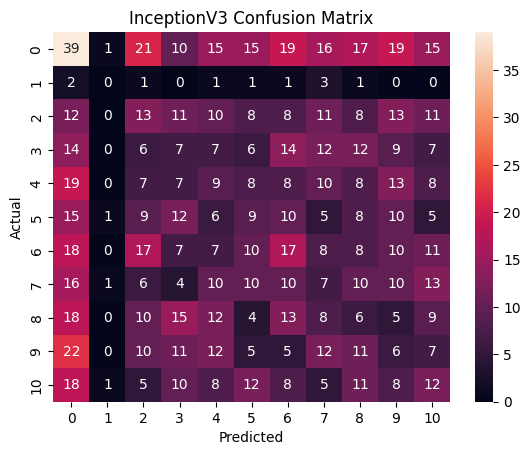

35/35 ━━━━━━━━━━━━━━━━━━━━ 27s 782ms/step


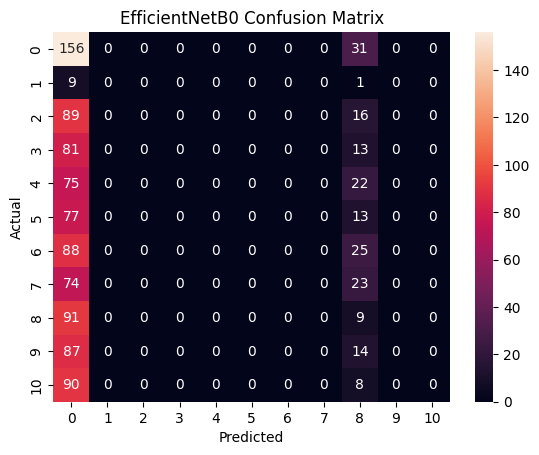

In [32]:
for name, model in models.items():
    
    y_pred = model.predict(val_generator)
    y_pred = np.argmax(y_pred, axis=1)
    y_true = val_generator.classes
    
    cm = confusion_matrix(y_true, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(name + " Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

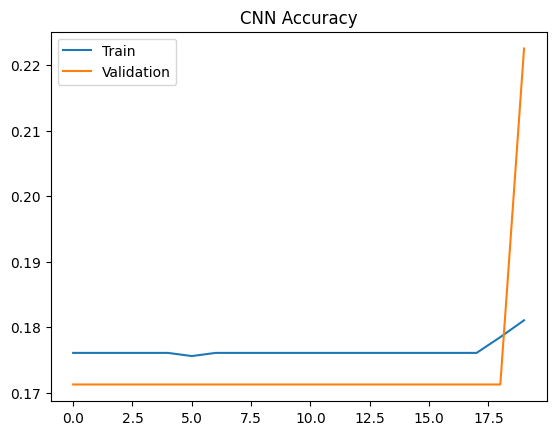

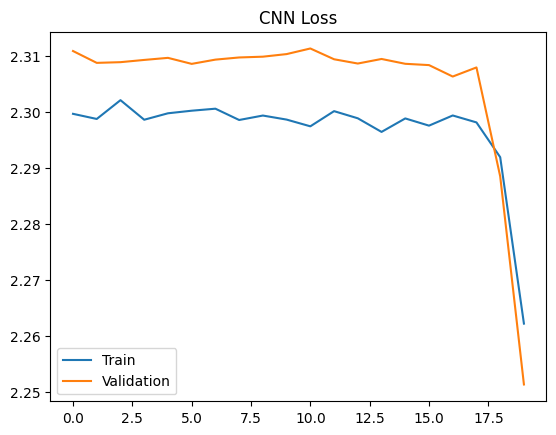

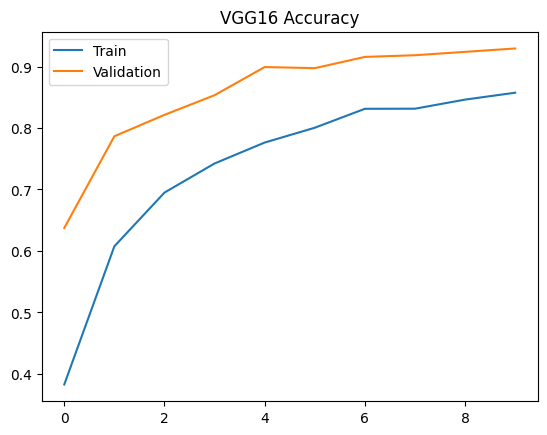

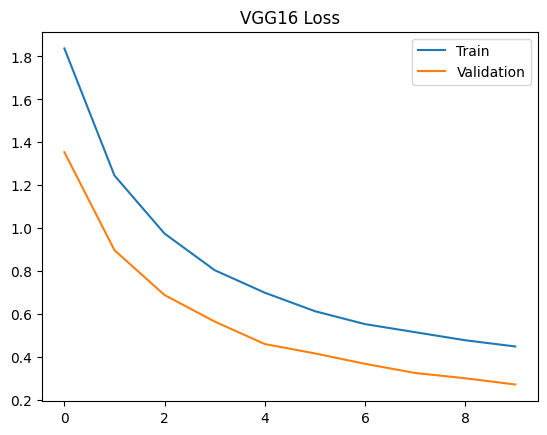

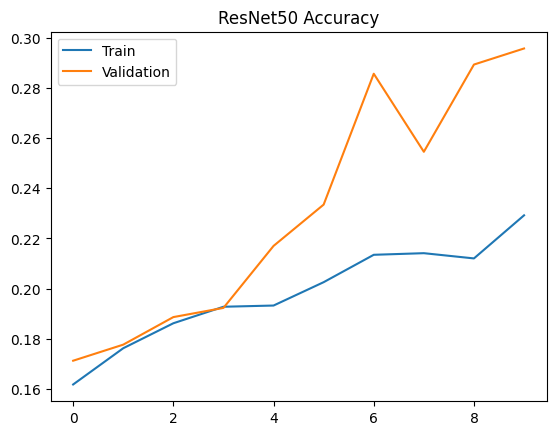

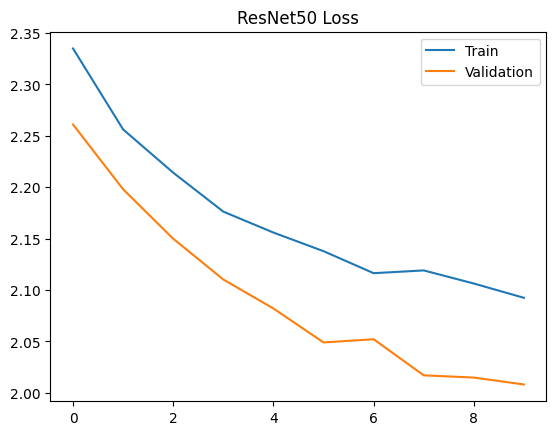

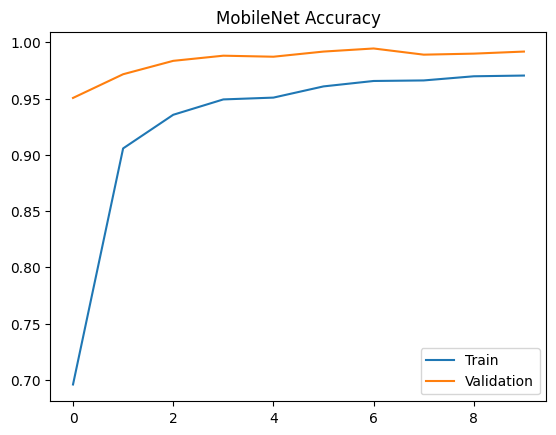

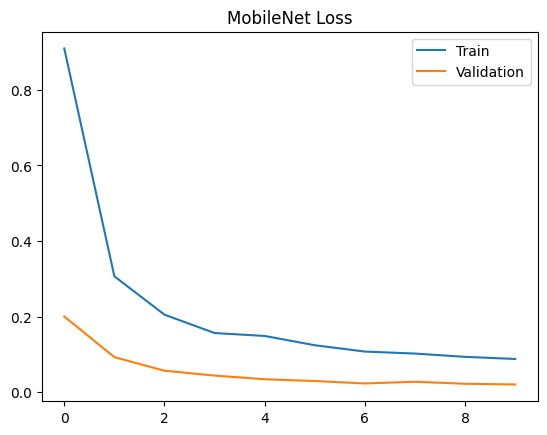

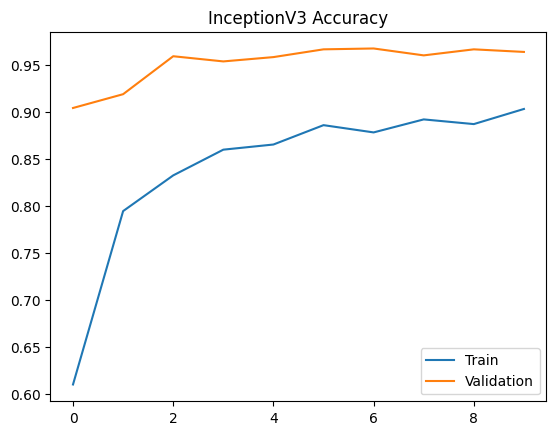

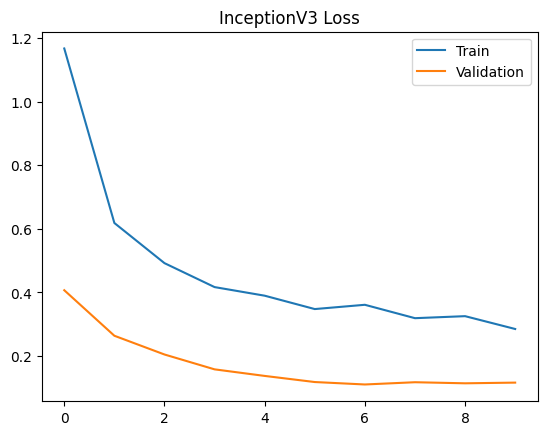

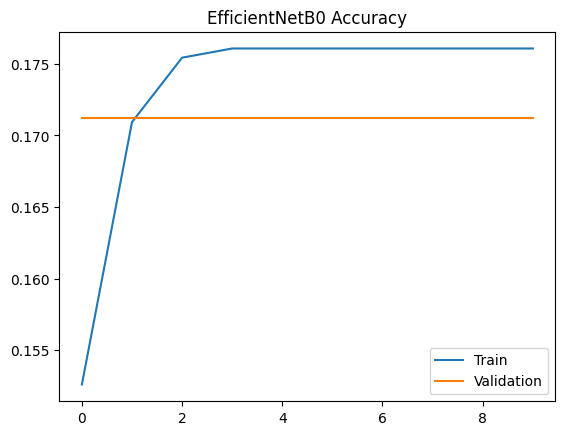

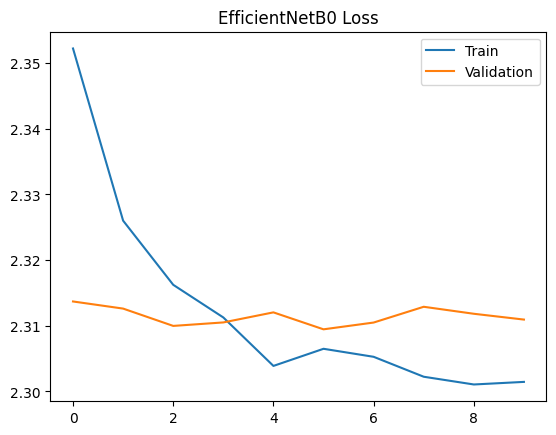

In [33]:
for name, history in histories.items():
    
    # Accuracy Graph
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(name + " Accuracy")
    plt.legend(['Train', 'Validation'])
    plt.show()
    
    # Loss Graph
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(name + " Loss")
    plt.legend(['Train', 'Validation'])
    plt.show()

In [34]:
print("\n📊 Final Model Accuracy Comparison")

for name, acc in results.items():
    print(name, ":", round(acc, 4))


📊 Final Model Accuracy Comparison
CNN : 0.152
VGG16 : 0.0897
ResNet50 : 0.1136
MobileNet : 0.1016
InceptionV3 : 0.0962
EfficientNetB0 : 0.1548
